# TinyChirp LEAF-Time TensorFlow

In [ ]:
%load_ext autoreload
%autoreload 2

In [3]:
from typing import TYPE_CHECKING


from utils import (
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("leaf_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)


2026-04-15 09:48:14.267583: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 09:48:14.395573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 09:48:14.452501: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 09:48:14.452743: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-15 09:48:14.543809: I tensorflow/core/platform/cpu_feature_gua

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/leaf_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


2026-04-15 09:48:18.545641: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 09:48:18.687068: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 09:48:18.688990: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print("Num labels:", num_labels)


Found 11292 files belonging to 2 classes.


2026-04-15 09:48:20.771815: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
Num labels: 2


In [5]:
import math
import numpy as np
import tensorflow as tf
import keras

class GaborConv1D(keras.layers.Layer):
    def __init__(self, num_filters, kernel_size, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride

        # We initialize frequencies more uniformly to ensure it catches high-pitch birds
        self.center_freqs = self.add_weight(shape=(1, 1, num_filters), initializer="random_uniform")
        self.bandwidths = self.add_weight(shape=(1, 1, num_filters), initializer="ones")

    def get_filters(self):
        limit = (self.kernel_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.kernel_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        env = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        cos_mod = tf.cos(2.0 * math.pi * self.center_freqs * t)
        sin_mod = tf.sin(2.0 * math.pi * self.center_freqs * t)
        return tf.concat([env * cos_mod, env * sin_mod], axis=-1)

    def call(self, inputs):
        conv = tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding='SAME')
        real, imag = tf.split(conv, 2, axis=-1)
        return tf.square(real) + tf.square(imag)


class GaussianPool1D(keras.layers.Layer):
    def __init__(self, num_filters, pool_size, stride, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.pool_size = pool_size
        self.stride = stride
        self.bandwidths = self.add_weight(shape=(1, num_filters, 1), initializer=tf.constant_initializer(0.4))

    def get_filters(self):
        limit = (self.pool_size - 1) / 2.0
        t = tf.cast(tf.linspace(-limit, limit, self.pool_size), tf.float32)
        t = tf.reshape(t, [-1, 1, 1]) 
        gauss = tf.exp(-0.5 * tf.square(t * self.bandwidths))
        return gauss / tf.reduce_sum(gauss, axis=0, keepdims=True)

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(
            tf.expand_dims(inputs, axis=1), 
            tf.expand_dims(self.get_filters(), axis=0), 
            strides=[1, 1, self.stride, 1], 
            padding='SAME'
        )[:, 0, :, :]


class LogCompression(keras.layers.Layer):
    """Instantly compresses audio without heavy loops. Perfect for CPU."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = 1e-6

    def call(self, inputs):
        return tf.math.log(inputs + self.epsilon)

In [6]:
NUM_FILTERS = 48
KERNEL_SIZE = 64
STRIDE = 16

NUM_FILTERS_2 = 16
KERNEL_SIZE_2 = 16
STRIDE_2 = 4

def build_training_model(num_labels: int) -> keras.Model:
    inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

    x = GaborConv1D(num_filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, stride=STRIDE, name="gabor_conv")(inputs)
    x = GaussianPool1D(num_filters=NUM_FILTERS, pool_size=KERNEL_SIZE, stride=1, name="gauss_pool")(x)
    x = keras.layers.Conv1D(
        filters=NUM_FILTERS_2, 
        kernel_size=KERNEL_SIZE_2, 
        strides=STRIDE_2,
        padding="same", 
        use_bias=False, 
        name="conv_1d_2")(x)
    x = keras.layers.ReLU(name="relu")(x)


    x = LogCompression(name="log_compress")(x)
    
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    outputs = keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    
    return keras.Model(inputs, outputs, name="leaf_fast_bird_model")


num_labels = 2 
training_model = build_training_model(num_labels)

# Use XLA compilation to speed up training
training_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    jit_compile=True  # This forces TF to optimize the custom math loops
)

In [7]:
training_model.summary()

Model: "leaf_fast_bird_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gabor_conv (GaborConv1D)        │ (None, 2992, 48)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gauss_pool (GaussianPool1D)     │ (None, 2992, 48)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1d_2 (Conv1D)              │ (None, 748, 16)        │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu (ReLU)                     │ (None, 748, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_compress (LogCompression)   │ (None, 748, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,650 (53.32 KB)

 Trainable params: 13,650 (53.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from utils import init_wandb, get_callbacks, finish_wandb

init_wandb("leaf_multilayer", config={
    "num_filters": NUM_FILTERS,
    "kernel_size": KERNEL_SIZE,
    "stride": STRIDE,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=50,
    callbacks=get_callbacks(10,5,32),
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/70


I0000 00:00:1776239308.538068    6655 service.cc:145] XLA service 0x7402f000a220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776239308.538132    6655 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-15 09:48:28.664396: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-15 09:48:29.143495: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  6/353 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4412 - loss: 4.0484

I0000 00:00:1776239313.339231    6655 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6707 - loss: 0.7505

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


353/353 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.7179 - loss: 0.5348 - val_accuracy: 0.8145 - val_loss: 0.3717
Epoch 2/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.8408 - loss: 0.3653 - val_accuracy: 0.9159 - val_loss: 0.2377
Epoch 3/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.8826 - loss: 0.2829 - val_accuracy: 0.9101 - val_loss: 0.2182
Epoch 4/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9072 - loss: 0.2340 - val_accuracy: 0.9522 - val_loss: 0.1468
Epoch 5/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9290 - loss: 0.1863 - val_accuracy: 0.9522 - val_loss: 0.1333
Epoch 6/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9328 - loss: 0.1720 - val_accuracy: 0.9457 - val_loss: 0.1448
Epoch 7/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.9348 - loss: 0.1718 - val_accuracy: 0.9565 - val_loss: 0.1464
Epoch 8/70
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.9400 - loss: 0.1600 - val_accurac

batch/accuracy,▁▁▁▃▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█▇▇▇▇▇█▇███████▇▇▇
batch/batch_step,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▆▅▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▂▂▁
epoch/accuracy,▁▄▅▆▇▇▇▇▇▇▇▇██████▇█████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▅▆▇▇▇▇▇▇▇▇██▇█▇▇██▇▇███▇████████████▇██
epoch/val_loss,█▅▅▃▃▃▃▃▂▃▂▂▂▂▂▂▁▂▂▂▂▁▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁
batch/accuracy,0.98816


In [9]:

class SquaredModulus(keras.layers.Layer):
    def call(self, inputs):
        real, imag = tf.split(inputs, 2, axis=-1)
        return tf.square(real) + tf.square(imag)

gabor_layer = training_model.get_layer("gabor_conv")
pool_layer = training_model.get_layer("gauss_pool")

baked_gabor = gabor_layer.get_filters().numpy()  
baked_gauss = pool_layer.get_filters().numpy()  

infer_inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))

x = keras.layers.Conv1D(
    filters=NUM_FILTERS * 2, 
    kernel_size=KERNEL_SIZE, 
    strides=STRIDE,
    padding="same", 
    use_bias=False, 
    name="baked_gabor_conv"
)(infer_inputs)
x = SquaredModulus(name="squared_modulus")(x)
x = keras.layers.DepthwiseConv1D(
    kernel_size=KERNEL_SIZE, 
    strides=1, 
    padding="same", 
    use_bias=False, 
    name="baked_gauss_dw"
)(x)
x = LogCompression(name="log_compress")(x)

for layer in training_model.layers[4:]:
    x = layer(x)

inference_model = keras.Model(infer_inputs, x, name="leaf_fast_bird_inference")

inference_model.get_layer("baked_gabor_conv").set_weights([baked_gabor])
inference_model.get_layer("baked_gauss_dw").set_weights([baked_gauss])

for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

ValueError: Input 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 16, but received input with shape (None, 48)

353it [00:33, 10.43it/s]
2026-04-10 14:42:41.560546: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
43it [00:04,  9.90it/s]2026-04-10 14:42:47.032026: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:04,  9.69it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.1971  (best F2 threshold)
Accuracy : 0.9663
Precision: 0.9152
Recall   : 0.9891
F2 score : 0.9734
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9978


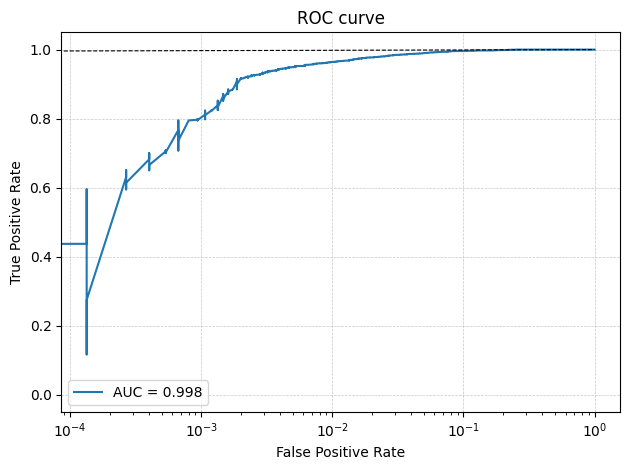

In [ ]:
from utils import get_flops_native
flops = get_flops_native(inference_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Total FLOPs: 18674498


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_21
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-10 14:42:48.653348: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 14:42:48.654834: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-10 14:42:48.654946: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-10 14:42:48.655845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful 

In [ ]:
rep_batches = build_representative_batches(test_ds, take=100)
export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
print(f"Success! Wrote {OUT_TFLITE}")

In [ ]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, "leaf_time_tf", train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")